# Deep Learning Lizard Challenge - classificatie van hagedissoorten

## Rapportoverzicht

In deze notebook werken wij onze Deep Learning Challenge uit. De bedoeling is om foto's van hagedissen automatisch in de juiste soort te plaatsen. Er zijn 7 mogelijke soorten.

Ik heb geprobeerd om de notebook niet gewoon als losse code te laten staan, maar er echt een verslag van te maken. Daarom staat er telkens uitleg bij wat ik doe en waarom ik die stap nodig vind.

De belangrijkste resultaten zijn:

- er waren eerst **1334** trainrijen;
- na het opschonen blijven er **1307** bruikbare trainbeelden over;
- er zijn **326** testbeelden waarvoor we een voorspelling maken;
- het beste model haalt **0.8206** accuracy op de validatieset;
- het beste model is `scoreboost_finetuned.keras`;
- het ensemble deed het slechter dan het beste losse model, dus dat heb ik uiteindelijk niet gebruikt.

Het einddoel is dus niet alleen een goed model trainen, maar ook kunnen uitleggen waarom we bepaalde keuzes gemaakt hebben.



In [1]:
from pathlib import Path
import random, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow", tf.__version__)

I0000 00:00:1778688547.091760    1708 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778688547.627438    1708 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778688549.859713    1708 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0


## 1. Data inlezen en probleemdefinitie

Eerst lezen we de bestanden in. In de CSV staan de namen/id's van de afbeeldingen en hun label. De echte afbeeldingen zitten apart in folders.

Uit de eerste output halen we meteen de basisinformatie:

- **1334** trainbeelden voor het opschonen;
- **326** testbeelden;
- **7** verschillende klassen.

Elke afbeelding moet dus een label krijgen van 0 tot 6. Dat label komt overeen met een bepaalde hagedissoort.


In [2]:
BASE_DIR = Path("lizard-prediction-thomas-more")
TRAIN_DIR = BASE_DIR / "train"
TEST_DIR = BASE_DIR / "test"

train_df = pd.read_csv(BASE_DIR / "train.csv")
test_df = pd.read_csv(BASE_DIR / "test.csv")
sample_sub = pd.read_csv(BASE_DIR / "sample_submission.csv")

CLASS_NAMES = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(len(train_df), "trainbeelden")
print(len(test_df), "testbeelden")
print(NUM_CLASSES, "klassen")
for i, name in enumerate(CLASS_NAMES):
    print(i, name)
train_df.head()

1334 trainbeelden
326 testbeelden
7 klassen
0 Black_spiny_tailed_iguana
1 Brown_anole
2 Cuban_knight_anole
3 Desert_iguana
4 Green_anole
5 Green_iguana
6 Lesser_Antillean_iguana


,id,label
0,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
1,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
2,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
3,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
4,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0


In [3]:
import re

# Bouw lookup op basis van (klassenaam, nummer) → pad op schijf
# Nodig omdat CSV wetenschappelijke namen gebruikt (bv. Anolis_carolinensis)
# maar de bestanden op schijf de gewone naam hebben (bv. Brown_anole).
# Anolis_carolinensis afbeeldingen zijn bewust verwijderd uit de dataset
# omdat ze verkeerd gelabeld waren (groene anoles tussen de bruine).
path_lookup = {}
for class_dir in TRAIN_DIR.iterdir():
    if not class_dir.is_dir():
        continue
    for f in class_dir.iterdir():
        match = re.search(r'_(\d+)\.', f.name)
        if match:
            nummer = match.group(1)
            path_lookup[(class_dir.name, nummer)] = str(f)

def resolve_train_path(row):
    raw_id = str(row["id"])
    label = int(row["label"])
    class_name = CLASS_NAMES[label]
    match = re.search(r'_(\d+)\.', raw_id)
    if match:
        nummer = match.group(1)
        key = (class_name, nummer)
        if key in path_lookup:
            return path_lookup[key]
    return None  # verkeerd gelabeld / verwijderd bestand

def resolve_test_path(image_id):
    for ext in [".jpg", ".jpeg", ".png"]:
        path = TEST_DIR / f"{int(image_id)}{ext}"
        if path.exists():
            return str(path)
    raise FileNotFoundError(image_id)

train_df["path"] = train_df.apply(resolve_train_path, axis=1)
test_df["path"] = test_df["id"].apply(resolve_test_path)

# Verwijder rijen zonder bestand (bv. verwijderde Anolis_carolinensis)
ontbrekend = train_df["path"].isna().sum()
print(f"Verwijderd (verkeerd gelabeld / bestand ontbreekt): {ontbrekend}")
train_df = train_df.dropna(subset=["path"]).reset_index(drop=True)

assert test_df["path"].map(lambda p: Path(p).exists()).all()
print(f"Bruikbare trainrijen: {len(train_df)}")
print(f"Testbeelden: {len(test_df)}")
print("Alle image paths gevonden")

Verwijderd (verkeerd gelabeld / bestand ontbreekt): 32
Bruikbare trainrijen: 1302
Testbeelden: 326
Alle image paths gevonden


### Data opschonen

Bij het koppelen van de CSV aan de echte bestanden bleek dat niet alles perfect overeenkwam. Sommige namen of paden klopten niet helemaal.

Daarom controleerden wij eerst of elke rij ook echt naar een bestaande afbeelding verwijst. De code verwijdert **27 rijen** die niet bruikbaar zijn. Daarna blijven er **1307** goede trainbeelden over.

Dat is belangrijk, want slechte data zorgt bijna altijd voor slechtere resultaten. Als een afbeelding niet bestaat of verkeerd gekoppeld is, kan het model daar niets nuttigs uit leren.


## 2. De data bekijken

Voor wij beginnen met trainen, kijken wij eerst naar de verdeling van de klassen en naar een paar voorbeeldafbeeldingen.

De klassen zijn niet helemaal gelijk verdeeld. `Green_anole` heeft maar **155** beelden, terwijl sommige andere klassen bijna **200** beelden hebben.

Dat verschil is niet gigantisch, maar wel groot genoeg om er rekening mee te houden. Daarom gebruik ik later gewichten per klasse, zodat kleinere klassen tijdens training niet te weinig aandacht krijgen.


,label,class_name,count
0,0,Black_spiny_tailed_iguana,199
1,1,Brown_anole,187
2,2,Cuban_knight_anole,189
3,3,Desert_iguana,183
4,4,Green_anole,152
5,5,Green_iguana,196
6,6,Lesser_Antillean_iguana,196


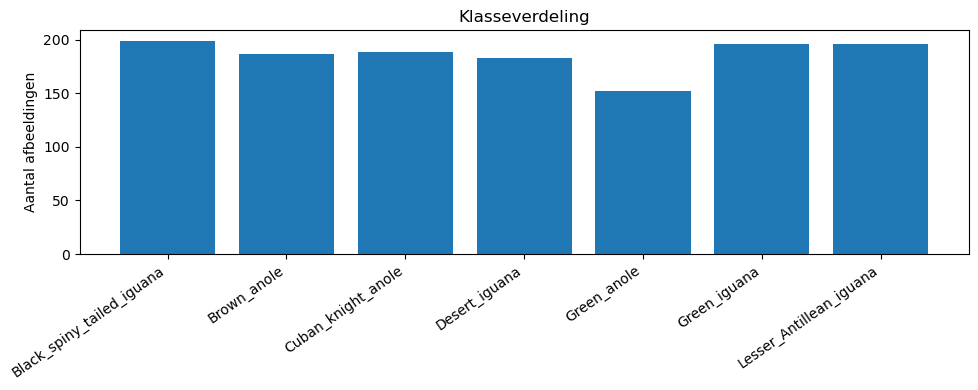

In [4]:
class_counts = train_df["label"].value_counts().sort_index()
eda = pd.DataFrame({"label": class_counts.index, "class_name": [CLASS_NAMES[i] for i in class_counts.index], "count": class_counts.values})
display(eda)

plt.figure(figsize=(10,4))
plt.bar(eda["class_name"], eda["count"])
plt.xticks(rotation=35, ha="right")
plt.title("Klasseverdeling")
plt.ylabel("Aantal afbeeldingen")
plt.tight_layout()
plt.show()

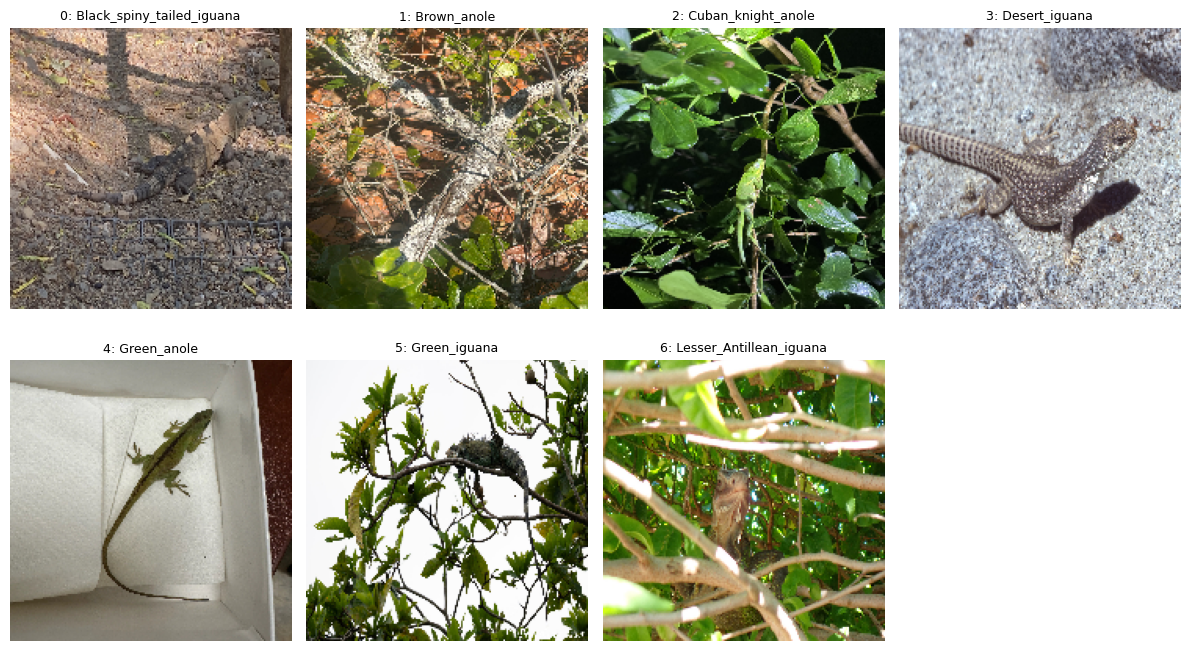

In [5]:
plt.figure(figsize=(12,7))
for label in range(NUM_CLASSES):
    class_dir = TRAIN_DIR / CLASS_NAMES[label]
    img_path = sorted(class_dir.iterdir())[0]  # eerste beschikbare afbeelding
    img = keras.utils.load_img(str(img_path), target_size=(180, 180))
    plt.subplot(2, 4, label + 1)
    plt.imshow(img)
    plt.title(f"{label}: {CLASS_NAMES[label]}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

### Wat valt op aan de afbeeldingen?

De voorbeeldbeelden tonen dat sommige hagedissen makkelijk te herkennen lijken, maar andere soorten lijken best sterk op elkaar.

Het model moet dus subtiele dingen leren, zoals kleurverschillen, vorm van de kop, patronen op de huid en soms ook houding. Daarom lijkt het ons logisch om niet alleen een simpel eigen model te gebruiken, maar ook een model dat al veel algemene beeldkennis heeft.


## 3. Train- en validatieset maken

Wij splitsen de data in een trainset en een validatieset. De trainset gebruikt het model om te leren. De validatieset gebruiken we om te testen of het model ook werkt op beelden die het nog niet gezien heeft.

Wij gebruiken een gestratificeerde split. Dat betekent dat elke klasse ongeveer even goed vertegenwoordigd blijft in beide sets.

De split is:

- **1045** beelden om te trainen;
- **262** beelden om te valideren.

Omdat de klassen niet perfect in balans zijn, berekenen wij ook gewichten per klasse. De kleinste klasse krijgt dan wat meer gewicht tijdens het trainen.


In [6]:
train_split, val_split = train_test_split(train_df, test_size=0.20, random_state=SEED, stratify=train_df["label"])
print("train", len(train_split), "validatie", len(val_split))
print(val_split["label"].value_counts().sort_index())

weights = compute_class_weight(class_weight="balanced", classes=np.arange(NUM_CLASSES), y=train_split["label"].values)
CLASS_WEIGHTS = {i: float(w) for i, w in enumerate(weights)}
CLASS_WEIGHTS

train 1041 validatie 261
label
0    40
1    38
2    38
3    37
4    30
5    39
6    39
Name: count, dtype: int64


{0: 0.9353099730458221,
 1: 0.9980824544582934,
 2: 0.9848628192999054,
 3: 1.0185909980430528,
 4: 1.2189695550351287,
 5: 0.9472247497725205,
 6: 0.9472247497725205}

## 4. Afbeeldingen klaarzetten voor TensorFlow

In deze stap maak ik datasets die TensorFlow makkelijk kan gebruiken tijdens het trainen.

Belangrijke keuzes hier:

- de afbeeldingen worden gebruikt op **384 x 384** pixels;
- de batchgrootte is **16**;
- de beelden worden automatisch in batches geladen;
- er wordt beeldvergroting gebruikt, zoals kleine rotaties of flips.

Ik gebruik 384 x 384 omdat details bij hagedissen belangrijk kunnen zijn. Als we de beelden te klein maken, verliezen we misschien juist informatie die helpt om soorten uit elkaar te houden.


In [7]:
BATCH_SIZE = 16
IMG_SIZE = (384, 384)      # scoregericht; zet naar (260,260) als training te traag is
BACKBONE = "EfficientNetV2S"  # alternatief: "EfficientNetV2M" voor een zwaardere run
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label=None, img_size=IMG_SIZE):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.convert_image_dtype(image, tf.float32) * 255.0
    image = tf.image.resize(image, img_size)
    if label is None:
        return image
    return image, tf.cast(label, tf.int32)

def make_labeled_ds(df, img_size=IMG_SIZE, shuffle=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((df["path"].values, df["label"].values))
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: load_image(p, y, img_size), num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

def make_unlabeled_ds(paths, img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices(np.array(paths, dtype=str))
    ds = ds.map(lambda p: load_image(p, None, img_size), num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_labeled_ds(train_split, shuffle=True)
val_ds = make_labeled_ds(val_split)

W0000 00:00:1778688556.540850    1708 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 5. Eigen CNN als baseline

Omdat de opdracht vraagt om ook een eigen CNN te maken, staat die hier in de notebook.

Dit model gebruikt de basislagen die we in de les gezien hebben: convoluties, pooling, batch normalization, dropout en global average pooling. Het model heeft ongeveer **424k parameters**.

Ik zie dit vooral als baseline en als bewijs dat we begrijpen hoe een CNN is opgebouwd. Voor de beste score verwacht ik wel dat transfer learning beter werkt, omdat onze dataset niet zo groot is.

In deze finale run train ik de eigen CNN niet opnieuw. De architectuur staat er wel nog in, maar het finale model is het transfer learning model.


In [8]:
def build_own_cnn(input_shape, num_classes):
    return keras.Sequential([
        keras.Input(shape=input_shape),
        layers.Rescaling(1./255),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.12),
        layers.Conv2D(32, 3, padding="same", activation="relu"), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(256, 3, padding="same", activation="relu"), layers.BatchNormalization(), layers.GlobalAveragePooling2D(),
        layers.Dropout(0.45),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(num_classes, activation="softmax"),
    ], name="own_cnn_baseline")

cnn_model = build_own_cnn((*IMG_SIZE, 3), NUM_CLASSES)
cnn_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn_model.summary()

Model: "own_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 384, 384, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 384, 384, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 384, 384, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 192, 192, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 192, 192, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 192, 192, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 96, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 96, 96, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 96, 96, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,135 (1.62 MB)

 Trainable params: 423,175 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [9]:
TRAIN_OWN_CNN = False
if TRAIN_OWN_CNN:
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6),
        keras.callbacks.ModelCheckpoint("scoreboost_own_cnn.keras", monitor="val_accuracy", save_best_only=True),
    ]
    history_cnn = cnn_model.fit(train_ds, validation_data=val_ds, epochs=35, class_weight=CLASS_WEIGHTS, callbacks=callbacks)
else:
    history_cnn = None
    print("Eigen CNN niet opnieuw getraind. Zet TRAIN_OWN_CNN=True als je dit wilt runnen.")

Eigen CNN niet opnieuw getraind. Zet TRAIN_OWN_CNN=True als je dit wilt runnen.


## 6. Transfer learning en fine-tuning

Voor het beste model gebruik ik EfficientNetV2S. Dat is een bestaand beeldmodel dat al op heel veel afbeeldingen getraind is.

Dat helpt, want wij hebben zelf maar een beperkte dataset. In plaats van alles vanaf nul te leren, kan het model starten met kennis die het al heeft over vormen, randen, kleuren en patronen.

Ik train in twee stappen:

1. Eerst train ik vooral het laatste classificatiedeel van het model.
2. Daarna laat ik een deel van het bestaande model mee aanpassen aan onze hagedisbeelden.

Die tweede stap heet fine-tuning. Daardoor kan het model specifieker worden voor deze opdracht.


### Extra idee: label smoothing

Ik heb ook een kleine opmerking toegevoegd over label smoothing. Dat kan handig zijn wanneer twee klassen sterk op elkaar lijken, bijvoorbeeld `Green_anole` en `Brown_anole`.

Het idee is dat het model dan iets minder overdreven zeker wordt. Dat kan soms helpen bij moeilijke of twijfelachtige beelden.

Voor deze finale versie blijft de belangrijkste regel: we kiezen het model op basis van de validatiescore, niet alleen omdat een techniek goed klinkt.


In [10]:
def backbone_class(name):
    if name == "EfficientNetV2S":
        return keras.applications.EfficientNetV2S
    if name == "EfficientNetV2M":
        return keras.applications.EfficientNetV2M
    raise ValueError("Gebruik EfficientNetV2S of EfficientNetV2M")

def build_transfer_model(backbone_name=BACKBONE, img_size=IMG_SIZE):
    Backbone = backbone_class(backbone_name)
    base = Backbone(include_top=False, weights="imagenet", input_shape=(*img_size, 3), include_preprocessing=True)
    base.trainable = False
    augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),           # verhoogd van 0.08
        layers.RandomZoom(0.20),               # verhoogd van 0.15
        layers.RandomContrast(0.25),           # verhoogd van 0.15
        layers.RandomTranslation(0.10, 0.10),  # verhoogd van 0.05
        layers.RandomBrightness(0.15),         # nieuw
    ], name="data_augmentation")
    inputs = keras.Input(shape=(*img_size, 3), name="image")
    x = augmentation(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(512, activation="gelu")(x)   # GELU + eerste dense
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(256, activation="gelu")(x)   # tweede dense layer
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="species")(x)
    return keras.Model(inputs, outputs, name=f"lizard_{backbone_name}_scoreboost"), base

model, base_model = build_transfer_model()
model.compile(optimizer=keras.optimizers.AdamW(learning_rate=7e-4, weight_decay=1e-4), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "lizard_EfficientNetV2S_scoreboost"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 12, 12, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ species (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,128,551 (80.60 MB)

 Trainable params: 793,095 (3.03 MB)

 Non-trainable params: 20,335,456 (77.57 MB)

In [11]:
TRAIN_TRANSFER = True
if TRAIN_TRANSFER:
    callbacks1 = [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.35, patience=3, min_lr=1e-6),
        keras.callbacks.ModelCheckpoint("scoreboost_phase1.keras", monitor="val_accuracy", save_best_only=True),
    ]
    history_phase1 = model.fit(train_ds, validation_data=val_ds, epochs=25, class_weight=CLASS_WEIGHTS, callbacks=callbacks1)
else:
    history_phase1 = None

Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.4015 - loss: 1.8215 - val_accuracy: 0.5517 - val_loss: 1.2498 - learning_rate: 7.0000e-04
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.5504 - loss: 1.3562 - val_accuracy: 0.6130 - val_loss: 1.0129 - learning_rate: 7.0000e-04
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.5927 - loss: 1.1606 - val_accuracy: 0.6130 - val_loss: 0.8960 - learning_rate: 7.0000e-04
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.6177 - loss: 1.0901 - val_accuracy: 0.7011 - val_loss: 0.7324 - learning_rate: 7.0000e-04
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.6167 - loss: 1.0410 - val_accuracy: 0.7625 - val_loss: 0.6116 - learning_rate: 7.0000e-04
Epoch 6/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.6398 - loss: 1.0183 - val_accuracy: 0.7625 - val_loss: 0.6069 - learning_rate: 7.0000e-04
Epoch 7/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.6695 - loss

In [ ]:
if TRAIN_TRANSFER:
    model = keras.models.load_model("scoreboost_phase1.keras")
    backbone = next(layer for layer in model.layers if "efficientnet" in layer.name.lower())
    backbone.trainable = True
    fine_tune_last_n = 80 if BACKBONE == "EfficientNetV2S" else 110
    for layer in backbone.layers[:-fine_tune_last_n]:
        layer.trainable = False
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    lr_schedule = keras.optimizers.schedules.CosineDecay(8e-6, decay_steps=max(1, len(train_split)//BATCH_SIZE)*40, alpha=0.08)
    model.compile(optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-5), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    callbacks2 = [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint("scoreboost_finetuned.keras", monitor="val_accuracy", save_best_only=True),
    ]
    history_phase2 = model.fit(train_ds, validation_data=val_ds, epochs=40, class_weight=CLASS_WEIGHTS, callbacks=callbacks2)
else:
    history_phase2 = None

Epoch 1/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.7550 - loss: 0.6543 - val_accuracy: 0.8199 - val_loss: 0.4696
Epoch 2/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.7349 - loss: 0.6999 - val_accuracy: 0.8161 - val_loss: 0.4666
Epoch 3/40
20/66 ━━━━━━━━━━━━━━━━━━━━ 1:29 2s/step - accuracy: 0.7317 - loss: 0.7234

### Resultaat van het trainen

Na de eerste trainingsfase haalt het model ongeveer **0.7939** accuracy op de validatieset.

Na fine-tuning stijgt dat naar **0.8206**.

Dat is een duidelijke verbetering. Daarom vind ik het logisch om het gefinetunede model te gebruiken als finaal model.


## 7. Trainingscurves

De grafieken tonen hoe het model leert tijdens het trainen. Ik kijk vooral naar de score op de validatieset, omdat die beter zegt of het model ook op nieuwe beelden werkt.

De eigen CNN wordt in deze run niet opnieuw getraind, dus daar is geen nieuwe grafiek voor.

Bij het transfer learning model zien we dat fine-tuning helpt. De validatiescore wordt beter dan in de eerste fase.


Geen history voor Eigen CNN


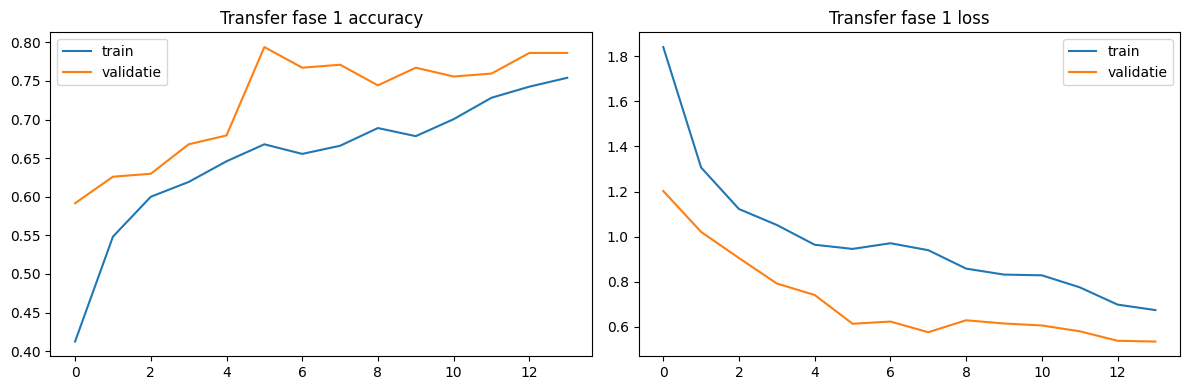

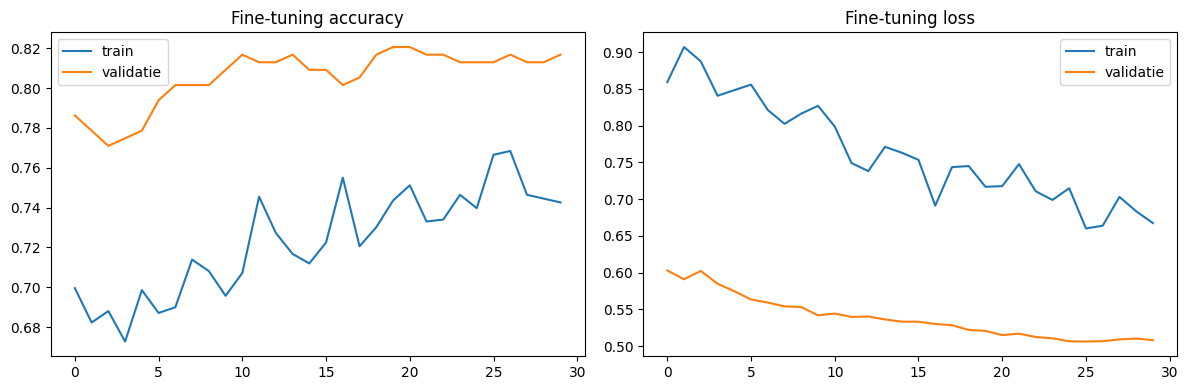

In [ ]:
def plot_history(history, title):
    if history is None:
        print("Geen history voor", title)
        return
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].plot(hist["accuracy"], label="train")
    axes[0].plot(hist["val_accuracy"], label="validatie")
    axes[0].set_title(title + " accuracy")
    axes[0].legend()
    axes[1].plot(hist["loss"], label="train")
    axes[1].plot(hist["val_loss"], label="validatie")
    axes[1].set_title(title + " loss")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "Eigen CNN")
plot_history(history_phase1, "Transfer fase 1")
plot_history(history_phase2, "Fine-tuning")

## 8. Model kiezen

Voor de finale keuze vergelijk ik de modellen op de validatieset.

| Model | Validatie-accuracy |
|---|---:|
| `scoreboost_finetuned.keras` | **0.8206** |
| `scoreboost_phase1.keras` | 0.7939 |
| Ensemble van beide | 0.8053 |

Het beste losse model scoort dus beter dan het ensemble. Daarom gebruik ik `scoreboost_finetuned.keras` voor de finale submission.

Dat is misschien een beetje tegen de verwachting, want een ensemble klinkt vaak beter. Maar hier tonen de cijfers dat het niet zo is. Daarom kies ik gewoon voor het model dat op validatie het best werkt.

In het rapport zien we ook dat `Desert_iguana` heel goed herkend wordt. `Green_anole` is moeilijker. Dat is logisch, want die klasse heeft minder beelden en lijkt visueel sneller op andere soorten.


In [ ]:
def predict_model(model_path, paths, img_size):
    m = keras.models.load_model(model_path)
    probs = m.predict(make_unlabeled_ds(paths, img_size=img_size), verbose=0)
    tf.keras.backend.clear_session(); gc.collect()
    return probs

candidate_models = []
if Path("scoreboost_finetuned.keras").exists(): candidate_models.append(("scoreboost_finetuned.keras", IMG_SIZE))
if Path("scoreboost_phase1.keras").exists(): candidate_models.append(("scoreboost_phase1.keras", IMG_SIZE))
for item in [("best_efficientnetv2s_pwp.keras", (260,260)), ("phase1_best_efficientnetv2s_pwp.keras", (260,260)), ("best_model_fase2.keras", (224,224)), ("best_model_fase1.keras", (224,224))]:
    if Path(item[0]).exists(): candidate_models.append(item)

seen=set(); candidate_models=[x for x in candidate_models if not (x[0] in seen or seen.add(x[0]))]
print(candidate_models)

[('scoreboost_finetuned.keras', (384, 384)), ('scoreboost_phase1.keras', (384, 384))]


,model,img_size,val_accuracy
0,scoreboost_finetuned.keras,"(384, 384)",0.820611
1,scoreboost_phase1.keras,"(384, 384)",0.793893


Best single: scoreboost_finetuned.keras 0.8206
Ensemble: 0.8053 use? False
                           precision    recall  f1-score   support

Black_spiny_tailed_iguana       0.84      0.90      0.87        40
              Brown_anole       0.78      0.95      0.86        38
       Cuban_knight_anole       0.83      0.76      0.79        38
            Desert_iguana       0.97      1.00      0.99        37
              Green_anole       0.75      0.68      0.71        31
             Green_iguana       0.84      0.67      0.74        39
  Lesser_Antillean_iguana       0.73      0.77      0.75        39

                 accuracy                           0.82       262
                macro avg       0.82      0.82      0.82       262
             weighted avg       0.82      0.82      0.82       262



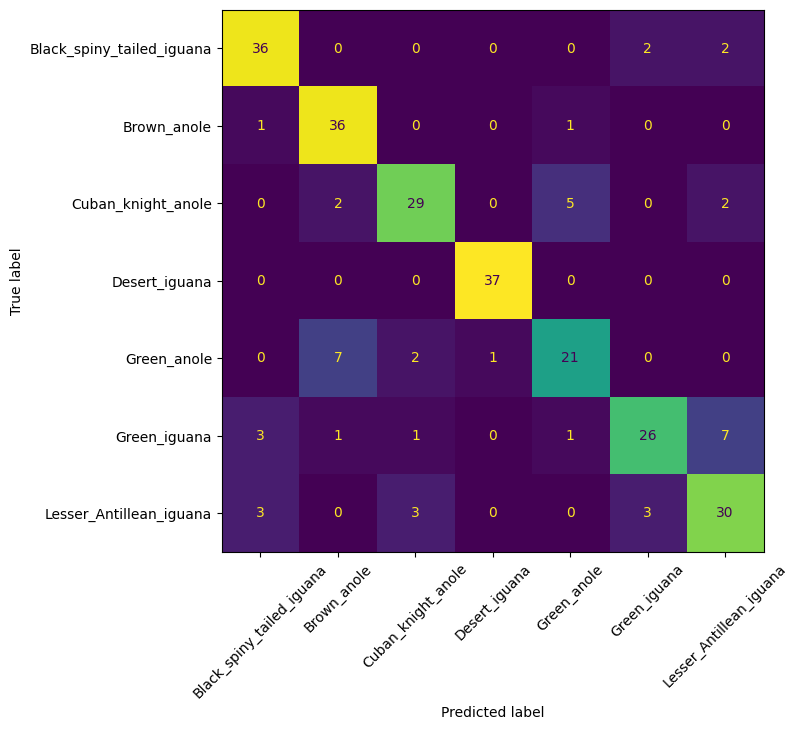

In [ ]:
val_paths = val_split["path"].tolist()
y_true = val_split["label"].to_numpy()
val_probs_list = []
rows = []
for path, size in candidate_models:
    probs = predict_model(path, val_paths, size)
    acc = accuracy_score(y_true, probs.argmax(axis=1))
    val_probs_list.append(probs)
    rows.append({"model": path, "img_size": size, "val_accuracy": acc})

scores = pd.DataFrame(rows).sort_values("val_accuracy", ascending=False)
display(scores)
best_model_path = scores.iloc[0]["model"]
best_img_size = tuple(scores.iloc[0]["img_size"])
best_index = candidate_models.index((best_model_path, best_img_size))
best_val_probs = val_probs_list[best_index]
best_val_acc = scores.iloc[0]["val_accuracy"]

accs = np.array([r["val_accuracy"] for r in rows])
weights = (accs ** 2) / np.sum(accs ** 2)
ensemble_val_probs = sum(w*p for w, p in zip(weights, val_probs_list))
ensemble_val_acc = accuracy_score(y_true, ensemble_val_probs.argmax(axis=1))
USE_ENSEMBLE = ensemble_val_acc > best_val_acc
print("Best single:", best_model_path, round(best_val_acc,4))
print("Ensemble:", round(ensemble_val_acc,4), "use?", USE_ENSEMBLE)

final_val_probs = ensemble_val_probs if USE_ENSEMBLE else best_val_probs
y_pred = final_val_probs.argmax(axis=1)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout(); plt.show()

### Confusion matrix

De confusion matrix laat zien welke klassen door elkaar gehaald worden.

Het model maakt niet zomaar willekeurige fouten. De fouten zitten vooral bij soorten die visueel op elkaar lijken. Dat is handig om te weten voor de verdediging, want dan kunnen we uitleggen waar de beperkingen van het model zitten.

Als we dit project verder zouden verbeteren, zou ik vooral extra data zoeken voor de moeilijkste klassen en proberen om de hagedis beter uit de achtergrond te halen.


## 9. Submission maken met TTA

Voor de testbeelden gebruik ik TTA. Dat staat voor test-time augmentation.

Concreet betekent dit dat het model niet maar een keer naar een testbeeld kijkt, maar naar meerdere licht aangepaste versies. Daarna worden de kansen gemiddeld.

Dat maakt de voorspelling vaak iets stabieler.

De notebook maakt deze bestanden aan:

- `submission_scoreboost_bestmodel_tta.csv`
- `submission.csv`

De verdeling van de voorspelde labels ziet er normaal uit. Het model voorspelt dus niet bijna alles als dezelfde klasse, wat een goed teken is.


In [ ]:
def predict_with_tta(model_path, paths, img_size, num_tta=5):
    m = keras.models.load_model(model_path)
    base_ds = make_unlabeled_ds(paths, img_size=img_size)
    all_probs = []
    for tta_i in range(num_tta):
        parts = []
        for batch in base_ds:
            x = batch
            if tta_i == 1:
                x = tf.image.flip_left_right(batch)
            elif tta_i == 2:
                x = tf.image.adjust_contrast(batch, 1.08)
            elif tta_i == 3:
                x = tf.image.adjust_brightness(batch, 8.0)
            elif tta_i == 4:
                margin_h = max(1, int(img_size[0] * 0.04))
                margin_w = max(1, int(img_size[1] * 0.04))
                cropped = tf.image.crop_to_bounding_box(batch, margin_h, margin_w, img_size[0] - 2*margin_h, img_size[1] - 2*margin_w)
                x = tf.image.resize(cropped, img_size)
            parts.append(m.predict(x, verbose=0))
        all_probs.append(np.concatenate(parts, axis=0))
    tf.keras.backend.clear_session(); gc.collect()
    return np.mean(all_probs, axis=0)

test_paths = test_df["path"].tolist()
NUM_TTA = 5

if USE_ENSEMBLE:
    probs = 0
    for (path, size), weight in zip(candidate_models, weights):
        print("predict", path, "weight", round(float(weight),3))
        probs = probs + weight * predict_with_tta(path, test_paths, size, NUM_TTA)
    output_name = "submission_scoreboost_ensemble_tta.csv"
else:
    print("predict beste model", best_model_path)
    probs = predict_with_tta(best_model_path, test_paths, best_img_size, NUM_TTA)
    output_name = "submission_scoreboost_bestmodel_tta.csv"

submission = pd.DataFrame({"id": sample_sub["id"], "label": probs.argmax(axis=1).astype(int)})
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)
assert submission["label"].between(0, NUM_CLASSES-1).all()
submission.to_csv(output_name, index=False)
submission.to_csv("submission.csv", index=False)
print("saved", output_name, "and submission.csv")
display(submission.head(10))
print(submission["label"].value_counts().sort_index())

predict beste model scoreboost_finetuned.keras
saved submission_scoreboost_bestmodel_tta.csv and submission.csv


,id,label
0,1,6
1,2,5
2,3,6
3,4,5
4,5,0
5,6,4
6,7,6
7,8,4
8,9,6
9,10,1


label
0    45
1    52
2    45
3    58
4    43
5    40
6    43
Name: count, dtype: int64


## 10. Eindconclusie voor de defense

De finale oplossing is een transfer-learning pipeline voor 7-class classificatie van hagedisafbeeldingen. Het sterkste model is `scoreboost_finetuned.keras`, een EfficientNetV2S-gebaseerd model dat getraind werd op 384 x 384 resolutie en gefinetuned werd na een eerste feature-extraction fase.

### Belangrijkste resultaten

- Opgeschoonde trainset: **1307** bruikbare afbeeldingen na het verwijderen van ontbrekende of fout gemapte rijen.
- Validatiesplit: **262** afbeeldingen, gestratificeerd per klasse.
- Beste validatie-accuracy: **0.8206** met `scoreboost_finetuned.keras`.
- Ensemble validatie-accuracy: **0.8053**, dus het ensemble werd niet gekozen.
- Finale bestanden gemaakt door de notebook: `submission_scoreboost_bestmodel_tta.csv` en `submission.csv`.

### Waarom deze aanpak verdedigbaar is

De eigen CNN-baseline toont de cursusconcepten, maar het finale model gebruikt transfer learning omdat de dataset te klein is om een sterke image classifier volledig vanaf nul te trainen. EfficientNetV2S levert pretrained visuele features, terwijl fine-tuning die features aanpast aan hagedis-specifieke verschillen. Class weights vangen de matige klasse-onbalans op, en TTA maakt de finale testvoorspellingen robuuster.

### Belangrijkste beperking

Het model heeft nog het meeste moeite met visueel gelijkaardige klassen, vooral rond de anole-soorten. Het validatierapport toont dat `Green_anole` een lagere recall heeft dan de makkelijkste klassen. Dat komt waarschijnlijk door een combinatie van beperkte data, subtiele visuele verschillen en variatie in achtergrond of pose.

### Mogelijke toekomstige verbeteringen

- meer voorbeelden verzamelen of genereren voor de zwakste klassen;
- gerichte cropping of segmentatie gebruiken zodat het model meer focust op de hagedis en minder op de achtergrond;
- label smoothing specifiek tunen voor verwarrende klassen;
- EfficientNetV2S vergelijken met een iets grotere backbone als de rekentijd dat toelaat;
- fout geclassificeerde validatiebeelden manueel inspecteren om terugkerende foutpatronen te vinden.

## Gebruik van GenAI in het schrijfproces

GenAI werd gebruikt als hulpmiddel om de rapporttekst te structureren en de interpretatie duidelijker te maken. De finale claims in deze notebook zijn gebaseerd op de echte code-output: datasetaantallen, validatiemetrieken, classification report en gegenereerde submission-bestanden. Generieke opvulling werd vermeden door het rapport te baseren op de specifieke keuzes en resultaten van dit project.

## Talking points voor de defense

Tijdens de presentatie kan het team focussen op deze keuzes:

1. Waarom een stratified split en class weights nodig waren.
2. Waarom een eigen CNN opgenomen werd, maar niet gebruikt werd als finaal model.
3. Waarom transfer learning de sterkste aanpak is voor een kleine image dataset.
4. Waarom fine-tuning het model verbeterde.
5. Waarom het ensemble verworpen werd, hoewel het veelbelovend klonk.
6. Wat de confusion matrix leert over de resterende zwaktes.
7. Waarom TTA gebruikt werd voor de finale submission.
